<a href="https://colab.research.google.com/github/KULDEEPSONI-source/DEEPLEARNING/blob/main/CNN_catvsdogPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
get_ipython().system('unzip /content/archive\\ \(1\).zip -d /content')

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_3577/2165317594.py:1: SyntaxWarning: invalid escape sequence '\('
  get_ipython().system('unzip /content/archive\\ \(1\).zip -d /content')


Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

In [48]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [36]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## `image_dataset_from_directory` — What's happening here

This code loads image data from folders and converts them into TensorFlow datasets ready for model training.

---

### How the folder structure works

```
/content/train/
    ├── cats/       ← class 0
    ├── dogs/       ← class 1
    └── birds/      ← class 2
```

Keras **infers the labels** from subfolder names automatically.

---

### Parameter breakdown

| Parameter | Value | Meaning |
|---|---|---|
| `directory` | `/content/train` | Root folder containing class subfolders |
| `labels` | `'inferred'` | Auto-detect labels from subfolder names |
| `label_mode` | `'int'` | Labels as integers (0, 1, 2…) — used with `SparseCategoricalCrossentropy` |
| `batch_size` | `32` | Load 32 images at a time |
| `image_size` | `(256, 256)` | Resize all images to 256×256 pixels |

---

### What each dataset is for

```python
train_ds       # Used to train the model — model sees and learns from this
validation_ds  # Used to evaluate during training — model never learns from this
```

---

### What the output looks like

Each dataset yields **batches** of `(images, labels)`:

```
images shape → (32, 256, 256, 3)   # 32 images, 256x256, RGB
labels shape → (32,)                # 32 integer labels
```

---

### Key thing about `label_mode='int'`

There are 3 options:

```python
label_mode='int'         # → [0, 1, 2]       use with SparseCategoricalCrossentropy
label_mode='categorical' # → [[1,0], [0,1]]  use with CategoricalCrossentropy
label_mode='binary'      # → [0, 1]           use with BinaryCrossentropy (2 classes only)
```

Since you used `'int'`, your loss function should be **`SparseCategoricalCrossentropy`**.

In [37]:

# ==========================================
# 3. DATA PREPROCESSING (NORMALIZATION)
# ==========================================
# Normalize pixel values from [0, 255] to [0, 1]
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [53]:
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================

model = Sequential()

# 1st convolutional Block
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
# 2nd convolutional Block
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2, activation='softmax')) # Corrected to 2 output units and lowercase 'softmax'
model.summary()


# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Corrected loss function string

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,258 (56.64 MB)

 Trainable params: 14,847,810 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.6023 - loss: 1.7087 - val_accuracy: 0.6304 - val_loss: 0.6401
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 100ms/step - accuracy: 0.7041 - loss: 0.5771 - val_accuracy: 0.5580 - val_loss: 1.1222
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7592 - loss: 0.5018 - val_accuracy: 0.7818 - val_loss: 0.4628
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7988 - loss: 0.4432 - val_accuracy: 0.7944 - val_loss: 0.4668
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 101ms/step - accuracy: 0.8317 - loss: 0.3892 - val_accuracy: 0.6190 - val_loss: 0.9085
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.8376 - loss: 0.3709 - val_accuracy: 0.8134 - val_loss: 0.4448
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.8878 - loss: 0.2676 - val_accuracy: 0.8064 - val_loss: 0.4813
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - accuracy: 0.9170 - loss: 0.209

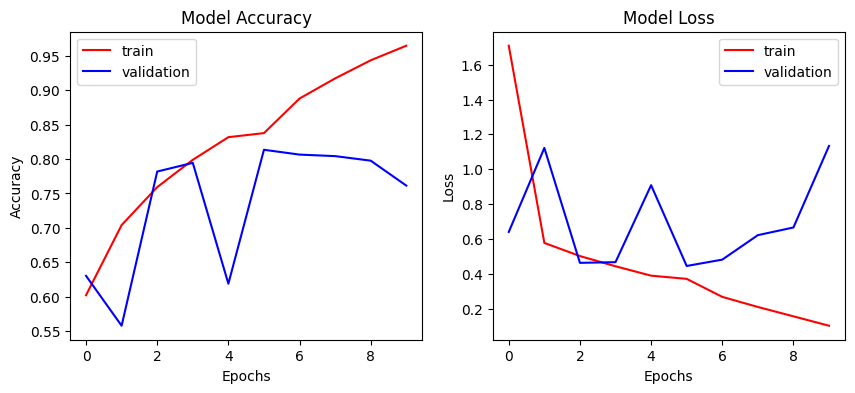

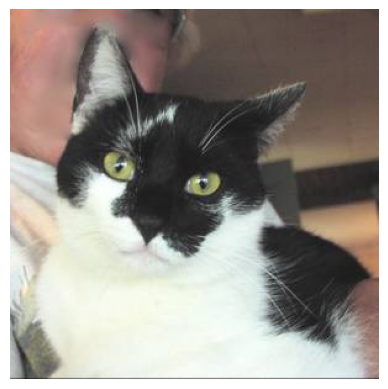

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Raw Prediction Value: 0.9995461106300354
Prediction: It's a CAT!


In [56]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
image_path = '/content/cat.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] > 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")

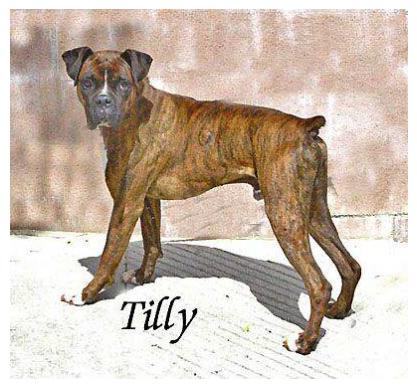

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Raw Prediction Value: 0.00016422505723312497
Prediction: It's a DOG!


In [57]:
# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
image_path = '/content/dog.991.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] > 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {image_path}. Please check your path.")